https://ryuzyproject.tistory.com/90

https://ryuzyproject.tistory.com/91

https://ryuzyproject.tistory.com/92

# 1. 시퀀스투시퀀스
시퀀스투시퀀스(Sequence-to-Sequence, Seq2Seq) 모델은 입력 시퀀스를 받아 출력 시퀀스를 생성하는 신경망 아키텍처로, 주로 자연어 처리 분야에서 번역, 요약, 질의응답 등에 활용됩니다. 

Seq2Seq 모델은 일반적으로 인코더(Encoder)와 디코더(Decoder) 두 부분으로 구성되며, 인코더는 입력 문장을 고정된 크기의 컨텍스트 벡터로 변환하고, 디코더는 이를 기반으로 출력 문장을 생성합니다. 

RNN, LSTM, GRU 등의 순환 신경망을 활용하며, 최근에는 어텐션 메커니즘과 트랜스포머 모델이 도입되어 더 긴 문맥을 효과적으로 처리할 수 있게 되었습니다. [논문](https://arxiv.org/abs/1409.3215)

- Seq2Seq는 입력 시퀀스를 받아 다른 출력 시퀀스로 바꾸는 구조
- 대표적인 예는 기계 번역
    - I love coffee > 나는 커피를 좋아해
    - I love coffee > Encoder > 문장 정보 압축 > Decoder > <BOS> 나는 / 커피를 / 좋아해 <EOS>
    - <BOS>: 문장 생성을 시작한다는 특별 토큰
    - <EOS>: 문장이 끝났다는 특별 토큰
    - Decoder는 이전에 생성한 토큰을 이용해 다음 토큰을 예측
- 고전적인 Seq2Seq는 보통 Encoder + Decoder로 구성되며, RNN/LSTM/GRU 등을 사용
    - Encoder: 입력을 순서대로 읽으며 hidden state에 정보를 누적
    - Decoder: Encoder가 만든 정보를 바탕으로 출력 토큰을 한 개씩 생성. 이전에 생성한 토큰을 이용해 다음
      토큰을 예측. Autoregressive(자기회귀)

![seq](./image%201.png)

### Seq2Seq의 문제점

- 초기 Seq2Seq는 Encoder의 마지막 hidden state 하나를 Decoder에 전달하는 방식이 많이 사용되었음
- 짧은 문장이라면 괜찮지만 문장이 길어지면 마지막 hidden state 하나가 앞부분의 세부 정보까지 모두 기억해야 함. 이처럼 많은 정보를 제한된 하나의 표현에 압축하면서 중요한 정보가 손실될 수 있음(정보 병목, Bottleneck)
- RNN은 t 시점 계산 > t+1 시점 계산처럼 앞 계산이 끝나야 다음 계산을 할 수 있으므로 긴 문장에서 학습이 느리고 병렬 처리에도 불리

# 1. 어텐션 메커니즘
기존의 RNN(Recurrent Neural Network)이나 LSTM(Long Short-Term Memory) 모델은 입력 데이터를 순차적으로 처리하기 때문에 긴 문장에서 중요한 정보를 잃어버리거나, 멀리 떨어진 단어 간의 관계를 잘 파악하지 못하는 문제가 있었습니다. 

어텐션은 입력 문장의 모든 단어를 한 번에 보고, 어떤 단어가 중요한지 가중치를 계산하여 집중하는 방법입니다.

예를 들어, "나는 오늘 학교에서 수학 시험을 봤다.

"라는 문장에서 "시험"이라는 단어가 가장 중요한 의미를 가진다고 가정합시다. 

어텐션은 이 문장을 처리할 때 "시험"에 더 높은 가중치를 주고, 덜 중요한 단어에는 낮은 가중치를 주는 방식으로 학습합니다.

In [2]:
import torch
import torch.nn as nn

torch.manual_seed(2026)

token = ['커피', '한잔', '어때']
token_ids = torch.tensor([0, 1, 2])
print('토큰: ', token)
print('토큰 ID: ', token_ids)
print('토큰 ID shape: ', token_ids.shape)

토큰:  ['커피', '한잔', '어때']
토큰 ID:  tensor([0, 1, 2])
토큰 ID shape:  torch.Size([3])


### 2. nn.Embedding

`nn.Embedding(num_embeddings=3, embedding_dim=4)`는 3행 * 4열의 학습 가능한 표

```text
Token ID 0(커피) > [실수, 실수, 실수, 실수]
Token ID 1(한잔) > [실수, 실수, 실수, 실수]
Token ID 2(어때) > [실수, 실수, 실수, 실수]
```
- `num_embeddings=3`: 사용할 수 있는 Token ID의 개수
- `embedding_dim=4`: 토큰 하나를 표현하는 숫자의 개수
- `embedding.weight.shape == (3, 4)`

In [3]:
embedding = nn.Embedding(num_embeddings=3, embedding_dim=4)
print(embedding)
print(embedding.weight)

X = embedding(token_ids)
print("임베딩 결과 X\n: ", X)
print("shape: ", X.shape)
print('토큰 수: ', X.shape[0])
print('임베딩 차원: ', X.shape[1])

Embedding(3, 4)
Parameter containing:
tensor([[ 0.3655,  1.9065,  0.2169,  0.2963],
        [-1.0160, -0.6064,  0.1744, -0.6306],
        [-0.0954,  0.3191, -1.4710,  0.2610]], requires_grad=True)
임베딩 결과 X
:  tensor([[ 0.3655,  1.9065,  0.2169,  0.2963],
        [-1.0160, -0.6064,  0.1744, -0.6306],
        [-0.0954,  0.3191, -1.4710,  0.2610]], grad_fn=<EmbeddingBackward0>)
shape:  torch.Size([3, 4])
토큰 수:  3
임베딩 차원:  4



### 3. Self-Attention

같은 시퀀스 안의 토큰들이 서로를 참고하는 Attention

```text
"커피 한잔 어때"

커피 > 커피, 한잔, 어때
한잔 > 커피, 한잔, 어때
어때 > 커피, 한잔, 어때
```

> 토큰이 3개이므로 관계 점수표는 3*3

> Transformer가 임베딩 그대로 복사해서 비교하는 것이 아니라, 서로 다른 학습 가능한 선형 변환을 거쳐 만듦

### 4. Query, Key, Value(Q, K, V)

- Query(Q): "나는 지금 어떤 정보를 찾고 있지?". `XW_Q`
- Key(K): "나는 어떤 특징을 가진 정보이지?". `XW_K`
- Value(V): "선택되면 실제로 전달할 내용은 이것이야". `XW_V`

In [4]:
embed_dim = 4
W_Q = nn.Linear(embed_dim, embed_dim, bias=False)
W_K = nn.Linear(embed_dim, embed_dim, bias=False)
W_V = nn.Linear(embed_dim, embed_dim, bias=False)

Q = W_Q(X)
K = W_K(X)
V = W_V(X)

print("X: ", X.shape)
print("Q: ", Q.shape)
print("K: ", K.shape)
print("V: ", V.shape)
print("Q = ", Q)
print("K = ", K)
print("V = ", V)

X:  torch.Size([3, 4])
Q:  torch.Size([3, 4])
K:  torch.Size([3, 4])
V:  torch.Size([3, 4])
Q =  tensor([[-0.3668, -0.8192,  0.1926, -0.0615],
        [ 0.0741,  0.5607, -0.4887, -0.2062],
        [-0.7271, -0.7872,  0.5736,  0.0966]], grad_fn=<MmBackward0>)
K =  tensor([[ 0.2404, -0.5815,  0.5650, -0.2048],
        [-0.4260,  0.1304, -0.2097,  0.2134],
        [ 0.6014, -0.1235,  0.1331,  0.7654]], grad_fn=<MmBackward0>)
V =  tensor([[ 0.1731,  0.7597, -0.1451,  0.0721],
        [-0.0511,  0.2425,  0.5725, -0.4278],
        [-0.2781, -0.3329, -0.1504,  0.5977]], grad_fn=<MmBackward0>)


- 현재 토큰의 Query와 모든 토큰의 Key를 내적하여 관련도 점수를 계산

```python
scores = Q @ K.T
```

- Q: `(3, 4)`
- K.T: `(4, 3)`
- 결과: `(3, 3)`

> 결과의 행(row)은 질문하는 Query 토큰, 열(column)은 참고 대상 Key 토큰

> 예) `scores[0, 2]`는 커피의 Query와 어때의 Key를 비교한 원시 점수

In [5]:
scores = Q @ K.T
print("Q shape: ", Q.shape)
print("K.T shape: ", K.T.shape)
print("scores shape: ", scores.shape)
print(scores)

Q shape:  torch.Size([3, 4])
K.T shape:  torch.Size([4, 3])
scores shape:  torch.Size([3, 3])
tensor([[ 0.5096, -0.0041, -0.1408],
        [-0.5422,  0.1000, -0.2476],
        [ 0.5872,  0.1074, -0.1898]], grad_fn=<MmBackward0>)


### Q와 K를 곱하는 이유
- 현재 단어의 Query와 다른 단어들의 Key를 비교하면 현재 단어가 다른 단어와 얼마나 관련 있는지 나타내는 점수를 만들 수 있음
- 점수(Score 행렬)
    - 행: 지금 보고 있는 토큰
    - 열: 비교 대상 토큰
    - [0, 2]위치의 값은 "커피"의 Query와 "어때"의 Key의 관계 점수
    - 단순히 관련도를 나타내는 원시 점수(raw score)

In [6]:
for i, query_token in enumerate(token):
    print(f'[{query_token}]가 바라보는 점수')

    for j, key_token in enumerate(token):
        print(f' > {key_token:4s}: {scores[i, j].item():.3f}')

[커피]가 바라보는 점수
 > 커피  : 0.510
 > 한잔  : -0.004
 > 어때  : -0.141
[한잔]가 바라보는 점수
 > 커피  : -0.542
 > 한잔  : 0.100
 > 어때  : -0.248
[어때]가 바라보는 점수
 > 커피  : 0.587
 > 한잔  : 0.107
 > 어때  : -0.190


In [7]:
import math

d_k = K.size(-1)
scaled_scores = scores / math.sqrt(d_k)
print("d_k: ", d_k)
print("sqrt(d_k): ", math.sqrt(d_k))
print(scaled_scores)

d_k:  4
sqrt(d_k):  2.0
tensor([[ 0.2548, -0.0021, -0.0704],
        [-0.2711,  0.0500, -0.1238],
        [ 0.2936,  0.0537, -0.0949]], grad_fn=<DivBackward0>)


### 7. Softmax로 Attention Weight 만들기
- Scaled Score는 아직 음수나 큰 양수가 섞인 원시 점수
- 각 행에 Softmax를 적용하면 값이 0~1 사이가 되고 각 행의 값이 1이됨
- 예) 한 Query의 Attention Weight가 [0.2, 0.6, 0.2] 라면 현재 토큰의 새 표현을 만들 때 첫 번째 Value를 20%, 두 번째를 60%, 세 번째를 20% 정도 반영한다는 뜻
- 이 값은 분류 문제의 "정답 확률"이라기보다 Value를 얼마나 참고하여 섞을지 나타내는 가중치

In [8]:
attention_weights = torch.softmax(scaled_scores, dim=-1)
print("Attention Weights")
print(attention_weights)
print("각 행의 합")
print(attention_weights.sum(dim=-1))

Attention Weights
tensor([[0.4007, 0.3099, 0.2894],
        [0.2827, 0.3897, 0.3276],
        [0.4057, 0.3192, 0.2751]], grad_fn=<SoftmaxBackward0>)
각 행의 합
tensor([1., 1., 1.], grad_fn=<SumBackward1>)


### 8. Attention Weight와 Value를 곱하기

- Attention Weight를 이용해 Value들을 가중합

```python
output = attention_weights @ V
```

커피 0.2 / 한잔 0.5 / 어때 0.3

새로운 커피 벡터는 개념적으로

커피의 V * 0.2 + 한잔의 V * 0.5 + 어때의 V * 0.3
```

> 위 만들어진 벡터에는 자기 자신의 정보뿐 아니라 문맥상 필요한 다른 토큰의 정보도 함께 반영

In [9]:
output = attention_weights @ V
print("V shape: ", V.shape)
print("attention_weights shape: ", attention_weights.shape)
print("output shape: ", output.shape)
print(output)

V shape:  torch.Size([3, 4])
attention_weights shape:  torch.Size([3, 3])
output shape:  torch.Size([3, 4])
tensor([[-0.0270,  0.2832,  0.0757,  0.0693],
        [-0.0621,  0.2002,  0.1328,  0.0494],
        [-0.0226,  0.2940,  0.0825,  0.0571]], grad_fn=<MmBackward0>)


### Self-Attention 전체 흐름

```text
입력 x
> Q, K, V 생성
> 토큰 사이의 원시 관계 점수
> 점수 크기 안정화
> Softmax
> Attention Weight @ V
  (필요한 정보를 가중합)
> 문맥이 반영된 출력
```

`Attention(Q, K, V) = softmax(QKᵀ / √d_k)V`

In [10]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    # 1. Key 벡터의 차원
    d_k = K.size(-1)

    # 2. Q와 K의 내적으로 관계 점수 계산
    scores = Q @ K.transpose(-2, -1)

    # 3. 차원의 제곱근으로 나누어 점수 크기 조절
    scores = scores / math.sqrt(d_k)

    # 4. 필요하면 Mask 적용
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))

    # 5. Softmax를 이용해 Attention Weight 계산
    weights = torch.softmax(scores, dim=-1)

    # 6. Attention Weight를 이용해 Value를 가중합
    output = weights @ V

    return output, weights


attention_output, weights = scaled_dot_product_attention(Q, K, V)

print("Attention Output:")
print(attention_output)

print("\nAttention Weights:")
print(weights)

Attention Output:
tensor([[-0.0270,  0.2832,  0.0757,  0.0693],
        [-0.0621,  0.2002,  0.1328,  0.0494],
        [-0.0226,  0.2940,  0.0825,  0.0571]], grad_fn=<MmBackward0>)

Attention Weights:
tensor([[0.4007, 0.3099, 0.2894],
        [0.2827, 0.3897, 0.3276],
        [0.4057, 0.3192, 0.2751]], grad_fn=<SoftmaxBackward0>)


### 9. Padding Mask
- 배치 학습에서는 여러 문장을 하나의 텐서로 묶기 위해 길이를 맞춰야 함
```
커피 한잔 어때
안녕 <PAD> <PAD>
```
- \<PAD\>는 길이를 맞추기 위한 자리 채움 토큰일 뿐 의미가 없음
- Attention이 PAD를 참고하지 못하도록 Padding Mask를 적용
- Mask된 Score를 -inf로 바꾸면 Softmax 후 해당 위치의 가중치는 0이 됨
```
score: [2.0, 1.0, 0.5, -inf]
softmax: [..., ..., ..., 0.0]
```
> PAD를 Attention의 참고 대상에서 제외하는 방법

In [11]:
sample_scores = torch.tensor([[2.0, 1.0, 0.5, 3.0]])
padding_mask = torch.tensor([1, 1, 1, 0])
masked_scores = sample_scores.masked_fill(padding_mask==0, float("-inf"))
weights_before = torch.softmax(sample_scores, dim=-1)
weights_after = torch.softmax(masked_scores, dim=-1)

print("Mask 전: ", weights_before)
print("Mask 후: ", weights_after)

Mask 전:  tensor([[0.2321, 0.0854, 0.0518, 0.6308]])
Mask 후:  tensor([[0.6285, 0.2312, 0.1402, 0.0000]])


# 1. 트랜스포머
트랜스포머(Transformer)는 2017년 구글 논문([Attention is all you need](https://arxiv.org/abs/1706.03762))에서 발표된 자연어 처리(NLP)와 다양한 시퀀스 학습 문제에서 뛰어난 성능을 보이는 신경망 아키텍처로, 어텐션 메커니즘을 활용하여 병렬 연산이 가능하고 장기 의존성을 효과적으로 처리할 수 있습니다. 기존의 순환신경망(RNN)과 달리 순차적인 계산 없이 전체 입력 문장을 한 번에 처리하며, 특히 "셀프 어텐션(Self-Attention)"을 사용하여 문장 내 단어 간 관계를 동적으로 학습합니다. 

대표적인 트랜스포머 기반 모델로는 BERT, GPT, T5 등이 있으며, 머신 번역, 텍스트 생성, 문서 요약 등 다양한 AI 분야에서 널리 활용되고 있습니다.

### 1. Multi-Head Attention
- Self-Attention을 한 세트의 Q/K/V로만 계산하면 하나의 표현 공간에서 관계를 학습함
- Multi-Head Attention은 여러 개의 Head가 서로 다른 Q/K/V 투영을 학습하여 다양한 관계를 동시에 포착할 수 있게 함
- 학습 결과에 따라 어떤 Head는 가까운 토큰 관계, 다른 Head는 문법적 관계나 의미적 관계 등에 반응할 수 있음
- 각 Head가 반드시 특정 역할을 담당한다고 미리 정해지는 것은 아님

```
embed_dim = 512
num_heads = 8
head_dim = 512 / 8 = 64
```

In [12]:
embed_dim = 8
num_heads = 2
head_dim = embed_dim // num_heads
print('전체 임베딩 차원: ', embed_dim)
print('Head의 개수: ', num_heads)
print('Head 하나의 차원: ', head_dim)

# batch:1, token=3, embed_dim=8
x = torch.randn(1, 3, embed_dim)
print('입력 shape: ', x.shape)

전체 임베딩 차원:  8
Head의 개수:  2
Head 하나의 차원:  4
입력 shape:  torch.Size([1, 3, 8])


In [18]:
mha = nn.MultiheadAttention(
  embed_dim=8, 
  num_heads=2, 
  batch_first=True
)

attn_output, attn_weights = mha(
  query=x, 
  key=x, 
  value=x, 
  need_weights=True
)
print('입력 shape: ', x.shape)
print('출력 shape: ', attn_output.shape)
print('Attention Weight shape: ', attn_weights.shape)
print(attn_weights)

입력 shape:  torch.Size([1, 3, 8])
출력 shape:  torch.Size([1, 3, 8])
Attention Weight shape:  torch.Size([1, 3, 3])
tensor([[[0.3638, 0.3448, 0.2914],
         [0.3591, 0.3306, 0.3103],
         [0.3489, 0.4051, 0.2460]]], grad_fn=<MeanBackward1>)


In [21]:
attn_output, head_weights = mha(query=x, key=x, value=x, need_weights=True, average_attn_weights=False)

print('Head별 Attention Weight shape: ')
print(head_weights.shape)
print('Head 0: ', head_weights[0, 0])
print('Head 1: ', head_weights[0, 1])

Head별 Attention Weight shape: 
torch.Size([1, 2, 3, 3])
Head 0:  tensor([[0.3338, 0.4100, 0.2562],
        [0.3358, 0.4188, 0.2454],
        [0.3320, 0.5235, 0.1445]], grad_fn=<SelectBackward0>)
Head 1:  tensor([[0.3937, 0.2796, 0.3266],
        [0.3824, 0.2424, 0.3752],
        [0.3658, 0.2867, 0.3474]], grad_fn=<SelectBackward0>)


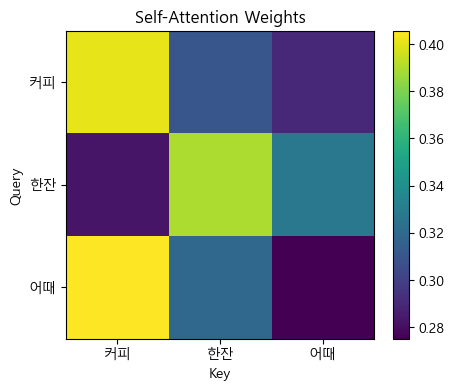

In [23]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정 (Windows)
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

# 밝거나 큰 값을 가진 위치일수록 해당 Query가 해당 Key를 더 많이 참고
weights_np = weights.detach().cpu().numpy()

plt.figure(figsize=(5, 4))
plt.imshow(weights_np)
plt.xticks(range(len(token)), token)
plt.yticks(range(len(token)), token)
plt.xlabel("Key")
plt.ylabel("Query")
plt.title("Self-Attention Weights")
plt.colorbar()
plt.show()

### 2. Transformer Encoder 흐름

```text
문장
> Tokenization
> Token ID
 === Encoding ===
> Token Embedding + Positional Encoding
 === Attention ===
> Multi-Head Self-Attention

> Residual Connection + LayerNorm

> Feed Forward Network(FFN)
> Residual Connection + LayerNorm
> Encoder 출력
```

In [24]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(2026)
torch.set_printoptions(precision=3, sci_mode=False)

vocab = {"<PAD>":0, "커피":1, "한잔":2, "어때":3}
tokens = ["커피", "한잔", "어때"]
token_ids = torch.tensor([[1, 2, 3]])

print(tokens)
print(token_ids)
print("shape:", token_ids.shape)

['커피', '한잔', '어때']
tensor([[1, 2, 3]])
shape: torch.Size([1, 3])


### Embedding
정수ID를 nn.Embdding에 넣어 d_model 차원의 실수 벡터로 바꿈
```
d_model=8
커피 > 1 > [8개의 실수]
한잔 > 2 > [8개의 실수]
어때 > 3 > [8개의 실수]
```
> 입력 shape는 (batch, sequence_length)이고, Embedding후에는 (batch, sequence_length, d_model)

In [29]:
vocab_size = len(vocab)
d_model = 8

embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
X = embedding(token_ids)

print(X)
print("shape:", X.shape)  # (batch, sequence_length, d_model)

tensor([[[ 0.338, -1.056,  0.397, -0.391, -0.689,  0.842,  0.313,  0.473],
         [-0.684, -0.950, -1.831, -0.796,  0.154,  1.260, -1.052, -0.560],
         [ 0.398,  0.506, -0.686,  0.209, -1.118,  1.640,  1.218,  0.576]]],
       grad_fn=<EmbeddingBackward0>)
shape: torch.Size([1, 3, 8])


### Positional Encoding: 순서 정보 넣기

- Self-Attention은 모든 토큰의 관계를 한 번에 계산하므로 RNN처럼 처리 순서 자체에서 위치 정보를 얻지 않음
- 입력에 위치 정보를 따로 넣어줌
- Transformer 논문은 고정된 Sin/Cos Positional Encoding을 사용
  - Transformer 입력 = Token Embedding + Positional Encoding

```text
커피 Embedding [0.20, -0.40, 0.70, ...]
0번 위치 Position [0.00, 1.00, 0.00, ...]
최종 입력 [0.20, 0.60, 0.70, ...]
```

> 모델이 각 숫자를 "단어 값"과 "위치 값"으로 따로 분리해 읽는 것은 아님. 같은 d_model 공간에서 두 정보를 더해 토큰의 의미 + 위치가 함께 들어있는 표현을 만드는 것

> 예) "나는 강아지를 좋아해"와 "강아지는 나를 좋아해"처럼 같은 단어가 등장해도 위치와 관계가 달라지면 의미가 달라질 수 있으므로 위치 정보가 중요

### Sin/Cos을 사용하는 이유

- 각 위치마다 여러 주기의 sin/cos 값을 조합하여 서로 다른 패턴을 만듦
- 값은 학습으로 바뀌는 파라미터가 아니라 공식으로 계산한 고정값
- 절대적인 위치 정보를 표현할 수 있음

### RoPE(Rotary Positional Embedding)

- 위치 정보를 입력 임베딩에 단순히 더하지 않음
- Attention을 계산할 때 사용하는 Q와 K에 위치 정보를 반영
- 토큰 위치에 따라서 Q와 K 벡터를 조금씩 회전시키는 방법
- 상대적인 위치 관계를 표현하는 데 유리함

```text
"나는 어제 학교에 갔다"

"나는" ↔ "갔다"
```

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()

        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)

        # 
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # 학습 파라미터가 아닌 고정 텐서이므로 buffer로 등록
        # pe는 공식으로 미리 계산해 놓은 고정값
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len]

pos_encoding = PositionalEncoding(d_model)
X_pos = pos_encoding(X)

print("Embedding:", X.shape)
print("Position 추가:", X_pos.shape)
print(X_pos)

Embedding: torch.Size([1, 3, 8])
Position 추가: torch.Size([1, 3, 8])
tensor([[[ 0.338, -0.056,  0.397,  0.609, -0.689,  1.842,  0.313,  1.473],
         [ 0.157, -0.410, -1.731,  0.199,  0.164,  2.260, -1.051,  0.440],
         [ 1.308,  0.090, -0.488,  1.189, -1.098,  2.639,  1.220,  1.576]]],
       grad_fn=<AddBackward0>)


In [32]:
num_heads = 2

mha = nn.MultiheadAttention(
    embed_dim=d_model,
    num_heads=num_heads,
    batch_first=True
)

attn_out, attn_weights = mha(
    query=X_pos, key=X_pos, value=X_pos,
    need_weights=True,
    average_attn_weights=False
)

print("입력:", X_pos.shape)
print("출력:", attn_out.shape)
print("Head별 Weight:", attn_weights.shape)

입력: torch.Size([1, 3, 8])
출력: torch.Size([1, 3, 8])
Head별 Weight: torch.Size([1, 2, 3, 3])


### Residual Connection(Skip Connection)

- Attention 결과만 다음 층으로 보내지 않고 원래 입력을 다시 더함

```text
y = x + F(x)
```

- x: Attention에 들어가기 전 원래 정보
- F(x): Attention이 계산한 변화 정보
- x + F(x): 원래 정보를 유지하면서 새 정보를 추가한 결과

In [36]:
x_original = X_pos[0, 0]
attention_change = attn_out[0, 0]
x_after_residual = x_original + attention_change

print("원래 입력 x        :", x_original)
print("Attention 결과 F(x):", attention_change)
print("Residual x + F(x)  :", x_after_residual)

# shape가 같아야 원소별 덧셈이 가능합니다.
print("x shape    :", x_original.shape)
print("F(x) shape :", attention_change.shape)

원래 입력 x        : tensor([ 0.338, -0.056,  0.397,  0.609, -0.689,  1.842,  0.313,  1.473],
       grad_fn=<SelectBackward0>)
Attention 결과 F(x): tensor([-0.150, -0.142,  0.358,  0.013,  0.258,  0.273,  0.040,  0.171],
       grad_fn=<SelectBackward0>)
Residual x + F(x)  : tensor([ 0.187, -0.198,  0.755,  0.621, -0.431,  2.116,  0.353,  1.644],
       grad_fn=<AddBackward0>)
x shape    : torch.Size([8])
F(x) shape : torch.Size([8])


In [38]:
norm1 = nn.LayerNorm(d_model)
# Residual Connection: Attention 입력 + Attention 출력
residual = X_pos + attn_out

x1 = norm1(residual)

print("전:", residual[0,0])
print("후:", x1[0,0])
print("평균:", x1[0,0].mean())
print("분산:", x1[0,0].var(unbiased=False))

전: tensor([ 0.187, -0.198,  0.755,  0.621, -0.431,  2.116,  0.353,  1.644],
       grad_fn=<SelectBackward0>)
후: tensor([-0.543, -1.014,  0.152, -0.012, -1.301,  1.818, -0.340,  1.241],
       grad_fn=<SelectBackward0>)
평균: tensor(0.000, grad_fn=<MeanBackward0>)
분산: tensor(1.000, grad_fn=<VarBackward0>)


### FeedForward Network(FFN)

- Attention: 토큰과 토큰 사이에 어떤 정보를 가져올지 계산
- FFN: Attention으로 모은 정보를 각 토큰 위치별로 독립적으로 비선형 변환

In [39]:
ffn = nn.Sequential(
    nn.Linear(d_model, 32),
    nn.ReLU(),
    nn.Linear(32, d_model)
)

ffn_out = ffn(x1)

print("입력:", x1.shape)
print("출력:", ffn_out.shape)

입력: torch.Size([1, 3, 8])
출력: torch.Size([1, 3, 8])


### 두 번째 Residual + Layer Normalization

- Encoder Block에는 두 개의 서브레이어가 있고 각각 Residual 연결이 붙음
  - Self-Attention > Residual > LayerNorm
  - FFN > Residual > LayerNorm

In [42]:

norm2 = nn.LayerNorm(d_model)

encoder_output = norm2(x1 + ffn_out)

print(encoder_output)
print(encoder_output.shape)

tensor([[[-0.494, -1.302,  0.311, -0.114, -1.088,  1.669, -0.347,  1.365],
         [ 0.155, -0.740, -1.276, -0.074,  0.457,  2.103, -1.008,  0.383],
         [ 0.416, -1.154, -0.955,  0.096, -1.359,  1.687,  0.441,  0.827]]],
       grad_fn=<NativeLayerNormBackward0>)
torch.Size([1, 3, 8])


In [ ]:
# Padding Mask 예제
padded_ids = torch.tensor([[1, 2, 3], [1, 3, 0]])
padding_mask = padded_ids.eq(0)

print(padded_ids)
print(padding_mask)
# False = 실제 토큰
# True  = PAD

tensor([[1, 2, 3],
        [1, 3, 0]])
tensor([[False, False, False],
        [False, False,  True]])


In [44]:

padded_x = pos_encoding(embedding(padded_ids))

# key_padding_mask: True인 key 위치는 참고 대상에서 제외
masked_out, masked_weights = mha(
    padded_x, padded_x, padded_x,
    key_padding_mask=padding_mask,
    need_weights=True
)

print(masked_weights)
print("\n두 번째 문장:")
print(masked_weights[1])

tensor([[[0.288, 0.415, 0.297],
         [0.342, 0.367, 0.290],
         [0.252, 0.439, 0.309]],

        [[0.478, 0.522, 0.000],
         [0.408, 0.592, 0.000],
         [0.465, 0.535, 0.000]]], grad_fn=<MeanBackward1>)

두 번째 문장:
tensor([[0.478, 0.522, 0.000],
        [0.408, 0.592, 0.000],
        [0.465, 0.535, 0.000]], grad_fn=<SelectBackward0>)


### Causal Mask

- Padding Mask: 의미 없는 `<PAD>` 위치를 가림
- Causal Mask: 현재 위치보다 뒤에 있는 미래 토큰을 가림

```text
"나는 커피를 마신다" 한 번에 입력해 학습되더라도 각 위치가 볼 수 있는 범위는 아래와 같음

Query    Key      나는      커피를      마신다
나는              O          X          X
커피를            O          O          X
마신다            O          O          O
```

In [45]:
seq_len = 3

# True = 가릴 위치 (미래 토큰)
causal_mask = torch.triu(
    torch.ones(seq_len, seq_len, dtype=torch.bool),
    diagonal=1
)

print(causal_mask)

causal_out, causal_weights = mha(
    X_pos, X_pos, X_pos,
    attn_mask=causal_mask,
    need_weights=True,
    average_attn_weights=False
)

print("Head별 weight shape:", causal_weights.shape)
print("첫 번째 head:")
print(causal_weights[0, 0])

tensor([[False,  True,  True],
        [False, False,  True],
        [False, False, False]])
Head별 weight shape: torch.Size([1, 2, 3, 3])
첫 번째 head:
tensor([[1.000, 0.000, 0.000],
        [0.373, 0.627, 0.000],
        [0.249, 0.484, 0.267]], grad_fn=<SelectBackward0>)


In [46]:
seq_len = 4

causal_mask = torch.triu(
    torch.ones(seq_len, seq_len, dtype=torch.bool),
    diagonal=1
)

print(causal_mask)

tensor([[False,  True,  True,  True],
        [False, False,  True,  True],
        [False, False, False,  True],
        [False, False, False, False]])


In [47]:
demo_x = torch.randn(1, seq_len, d_model)
causal_mha = nn.MultiheadAttention(d_model, num_heads=2, batch_first=True)

_, causal_weights = causal_mha(
    demo_x, demo_x, demo_x,
    attn_mask=causal_mask,
    need_weights=True
)

print("Causal Attention Weights:")
print(causal_weights[0])
print("\n미래 위치(오른쪽 위 삼각형)의 가중치가 0인지 확인하세요.")

Causal Attention Weights:
tensor([[1.000, 0.000, 0.000, 0.000],
        [0.703, 0.297, 0.000, 0.000],
        [0.230, 0.432, 0.337, 0.000],
        [0.223, 0.288, 0.189, 0.300]], grad_fn=<SelectBackward0>)

미래 위치(오른쪽 위 삼각형)의 가중치가 0인지 확인하세요.


In [48]:
class SimpleTransformerEncoderBlock(nn.Module):
    def __init__(self, d_model=8, num_heads=2, d_ff=32, dropout=0.1):
        super().__init__()

        self.self_attention = nn.MultiheadAttention(
            d_model, num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x, padding_mask=None):
        attn_out, weights = self.self_attention(
            x, x, x,
            key_padding_mask=padding_mask,
            need_weights=True
        )

        x = self.norm1(x + self.dropout1(attn_out))

        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out))

        return x, weights

block = SimpleTransformerEncoderBlock()
out, weights = block(X_pos)

print("입력:", X_pos.shape)
print("출력:", out.shape)
print("Weight:", weights.shape)

입력: torch.Size([1, 3, 8])
출력: torch.Size([1, 3, 8])
Weight: torch.Size([1, 3, 3])


### 3. Decoder

- Encoder: 입력 토큰 전체를 Self-Attention으로 처리하여 문맥이 반영된 표현을 만듦
- Decoder: 출력 문장을 생성
    - Masked Self-Attention: Decoder가 미래 출력 토큰을 미리 보지 못하게 함
    - Cross-Attention: Decoder가 Encoder 출력의 어느 부분을 참고할지 계산

Q = Decoder의 현재 표현
K = Encoder 출력
V = Encoder 출력

입력 > Encoder > Encoder Memory > 출력 입력 > Masked Self-Attention > Cross-Attention > FFN > Decoder > 출력

> GPT 같은 decoder-only 모델에는 별도의 Encoder와 Cross-Attention이 없는 일반적인 구성이 사용됨.

In [49]:
cross_attention = nn.MultiheadAttention(
    embed_dim=8,
    num_heads=2,
    batch_first=True
)

encoder_memory = torch.randn(1, 5, 8)
decoder_state = torch.randn(1, 3, 8)

cross_out, cross_weights = cross_attention(
    query=decoder_state,
    key=encoder_memory,
    value=encoder_memory
)

print("Q(Decoder):", decoder_state.shape)
print("K/V(Encoder):", encoder_memory.shape)
print("출력:", cross_out.shape)
print("Weight:", cross_weights.shape)

Q(Decoder): torch.Size([1, 3, 8])
K/V(Encoder): torch.Size([1, 5, 8])
출력: torch.Size([1, 3, 8])
Weight: torch.Size([1, 3, 5])


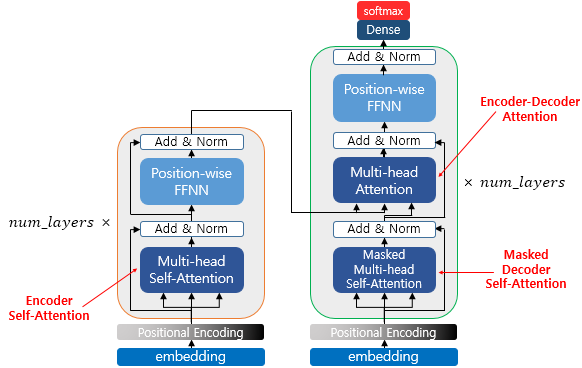